0
Accuracy: 0.9994557775359011

Confusion Matrix:
[[56849    15]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



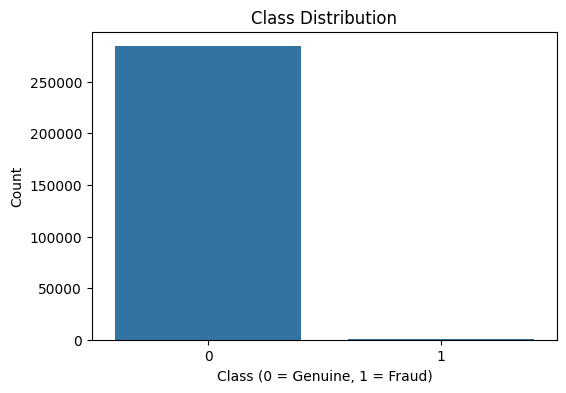

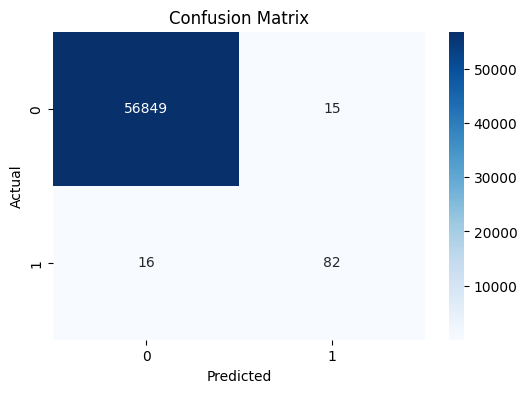


Top 10 Important Features:
   Feature  Importance
14     V14    0.195607
10     V10    0.110459
4       V4    0.106133
12     V12    0.095085
17     V17    0.085002
3       V3    0.060455
11     V11    0.056356
16     V16    0.043757
2       V2    0.036986
9       V9    0.026203


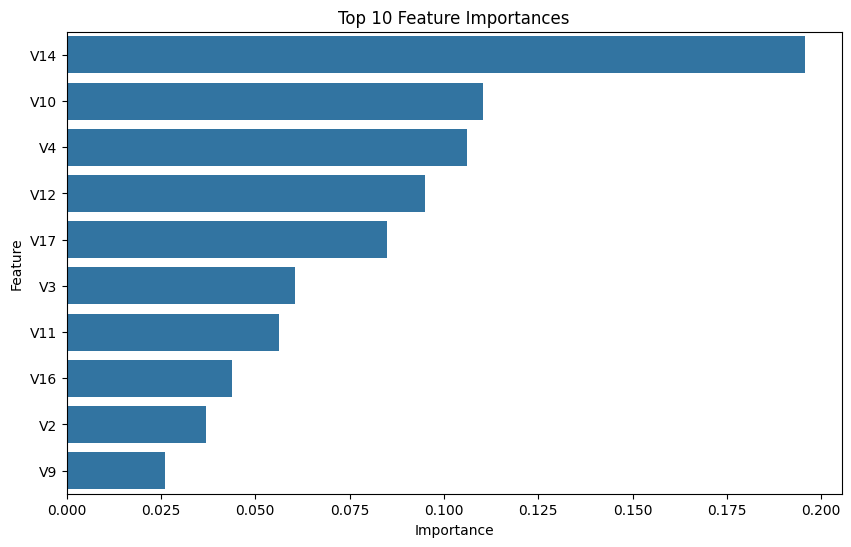

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("models", exist_ok=True)
os.makedirs("images", exist_ok=True)

# Load dataset
df = pd.read_csv("/content/creditcard.csv")



df = df.dropna(subset=["Class"])
print(df["Class"].isna().sum())
# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Scale Time and Amount
scaler = StandardScaler()
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # to make sure train data has equal amount of fraud ratios too
)


smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)
# Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,#100 decision trees
    random_state=42,
)

# Train
model.fit(X_train_resampled, y_train_resampled )



feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)  #which feature helped the most in prediction

# Predict
y_pred = model.predict(X_test)


joblib.dump(model, "models/fraud_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title('Class Distribution')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
plt.ylabel('Count')
plt.savefig('images/class_distribution.png')
plt.show()



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig('images/confusion_matrix.png')
plt.show()
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Feature Importances')
print("\nTop 10 Important Features:")
print(feature_importance.head(10))

plt.savefig('images/feature_importance.png')
plt.show()